#### ChatBot Reading Existing Memories

In [5]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from dotenv import load_dotenv
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.store.base import BaseStore
from langgraph.graph import START,END,StateGraph,MessagesState

In [3]:
store = InMemoryStore()

user_id = 'u1'
user_detail = ('user',user_id,'details')

store.put(user_detail,'profile1',{'data':'Name:Edward'})
store.put(user_detail,'profile2',{'data':'Proffesion: Student learning about AI and Automation'})
store.put(user_detail,'prefrence1',{'data':'Prefer consice answers'})
store.put(user_detail,'preference2',{'data':'Likes examples in Python'})
store.put(user_detail,'project1',{'data':'Building MCP servers (project in python)'})

In [17]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..."
say "Since your project is built with TypeScript..."

Use personalization especially in:
    Greetings and transitions
    Help or guidance tailored to tools and frameworks the user uses
    Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assume

In the end suggest 3 relevant further questions based on the current response and use

The user's memory (which may be empty) is provided as: {user_details_content}
"""

In [18]:
llm = ChatOpenAI(model='gpt-4o-mini')

In [19]:
def chat_node(state:MessagesState, config:RunnableConfig,store:BaseStore):
    user_id = config.get('configurable',{})['user_id']
    user_detail = ('user',user_id,'details')
    items = store.search(user_detail)

    if items:
        user_detail_content = "\n".join(f'-- {it.value.get('data','')}' for it in items)
    else:
        user_detail_content = '' 

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_details_content=user_detail_content)
    system_mssg = SystemMessage(content=system_prompt)

    res = llm.invoke([system_mssg]+state['messages']) #type:ignore

    return {'messages':[res]}

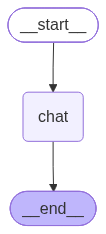

In [20]:
builder = StateGraph(MessagesState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [21]:
config = {'configurable':{'user_id':'u1'}}

result = graph.invoke({'messages':HumanMessage(content='Explain Gen AI in simple terms')},config=config) # type:ignore
print(result['messages'][-1].content)

Sure, Edward! Generative AI, often called Gen AI, refers to artificial intelligence systems that can create new content. This can include generating text, images, audio, or other forms of media. Think of it as a smart tool that learns from existing data and then produces something new that resembles it.

For example, if you feed a generative AI a lot of paintings, it can create its own unique artwork. Similarly, if you provide it with a dataset of text, it can write stories or articles based on the patterns it has learned.

In your case, as a student learning about AI, you might find it interesting to see how generative AI models like GPT (for text) or DALL-E (for images) operate by training on large amounts of data and then applying that knowledge to generate diverse outputs. 

Let me know if you’d like to dive deeper into any specific aspect!

Here are some relevant questions you might consider:
1. Are there any particular applications of Gen AI that interest you?
2. Would you like t

#### ChatBot Creating New Memories

In [5]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from dotenv import load_dotenv
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.store.base import BaseStore
from langgraph.graph import START,END,StateGraph,MessagesState
from pydantic import BaseModel, Field
import uuid
from typing import List

load_dotenv()

True

In [2]:
store = InMemoryStore()

In [3]:
extractor_llm = ChatOpenAI(model='gpt-4o-mini')

In [7]:
class MemoryDecision(BaseModel):
    should_write : bool = Field(description="whether to store any memories.")
    memories : List[str] = Field(default_factory=list, description="atomic user memories to store")

In [8]:
ext_llm_with_structure = extractor_llm.with_structured_output(MemoryDecision)

In [9]:
def remember_only_node(state:MessagesState, config:RunnableConfig, store:BaseStore):
    user_id = config.get('configurable',{})['user_id']
    namespace = ('user',user_id,'details')
    last_mssg = state['messages'][-1].content

    decision = ext_llm_with_structure.invoke([SystemMessage(content=("Extract Long term memories from user messages. \n"
                                                                     "Only store stable user specific info like(Identity, Prefrences, Ongoing Projects etc).\n"
                                                                     "Do  ot store transient info.\n"
                                                                     "Return should_write=False if nothing is worth storing.\n"
                                                                     "Each Memory should be a short atomic sentence.")
                                                            ),
                                                                     {'role':'user','content':last_mssg}
                                                        ]
                                                    )

    if decision.should_write:               #type:ignore
        for mem in decision.memories:       #type:ignore
            store.put(namespace,str(uuid.uuid4()),{'data':mem})

    return {'messages': [{'role':'assistant', 'content':'Noted.'}]}

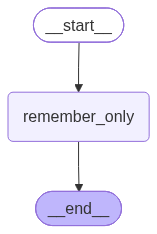

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("remember_only", remember_only_node)

builder.add_edge(START, "remember_only")
builder.add_edge("remember_only", END)

graph = builder.compile(store=store)

graph

In [15]:
config = {'configurable':{'user_id':'u1'}}

rez = graph.invoke({'messages':[HumanMessage(content='Hello my name is Edward.') ]},config=config) # type:ignore

print(rez['messages'][-1].content)

Noted.


d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryDecision(should_wri...ser's name is Edward."]), input_type=MemoryDecision])
  return self.__pydantic_serializer__.to_python(


In [16]:
rez = graph.invoke({'messages':[HumanMessage(content='I study AI from MIT.') ]},config=config) # type:ignore
print(rez['messages'][-1].content)

Noted.


d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryDecision(should_wri... studies AI from MIT.']), input_type=MemoryDecision])
  return self.__pydantic_serializer__.to_python(


In [17]:
rez = graph.invoke({'messages':[HumanMessage(content='My favourite programming language is Python.') ]},config=config) # type:ignore
print(rez['messages'][-1].content)

Noted.


d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryDecision(should_wri...g language is Python."]), input_type=MemoryDecision])
  return self.__pydantic_serializer__.to_python(


In [18]:
items = store.search(('user','u1','details'))

for it in items:
    print(it.value['data'])

User's name is Edward.
User studies AI from MIT.
User's favourite programming language is Python.
User's name is Edward.
User studies AI from MIT.
User's favourite programming language is Python.


#### ChatBot Creating Memories Without Duplication

In [63]:
store = InMemoryStore()

In [64]:
extractor_llm = ChatOpenAI(model='gpt-4o-mini')

In [65]:
class MemoryItem(BaseModel):
    text : str = Field(description='Atomic user memory as a short sentence')
    is_new : bool = Field(description='True if the memory is new and should be stored. False if Duplicate/already known.')

In [66]:
class MemoryDecision(BaseModel):
    should_write : bool = Field(description="whether to store any memories.")
    memories : List[MemoryItem] = Field(default_factory=list, description="atomic user memories to store")

In [67]:
ext_llm_with_structure = extractor_llm.with_structured_output(MemoryDecision)

In [68]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [69]:
def remember_only_node(state:MessagesState, config:RunnableConfig, store:BaseStore):
    user_id = config.get('configurable',{})['user_id']
    namespace = ('user',user_id,'details')
    last_mssg = state['messages'][-1].content
    user_details_content = "\n".join(f'-- {it.value.get('data','')}' for it in store.search(namespace))
    memory_mssg = MEMORY_PROMPT.format(user_details_content=user_details_content)
    decision = ext_llm_with_structure.invoke([SystemMessage(content=memory_mssg),
                                                            {'role':'user','content':last_mssg}
                                                    ]
                                                )

    if decision.should_write:               #type:ignore
        for mem in decision.memories:       #type:ignore
            if mem.is_new:
                store.put(namespace,str(uuid.uuid4()),{'data':mem.text})

    return {'messages': [{'role':'assistant', 'content':'Noted.'}]}

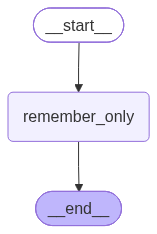

In [70]:
builder = StateGraph(MessagesState)
builder.add_node("remember_only", remember_only_node)

builder.add_edge(START, "remember_only")
builder.add_edge("remember_only", END)

graph = builder.compile(store=store)

graph

In [75]:
config = {'configurable':{'user_id':'u1'}}

rez = graph.invoke({'messages':[HumanMessage(content='Hello my name is Edward.') ]},config=config) # type:ignore

print(rez['messages'][-1].content)

Noted.


d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryDecision(should_write=False, memories=[]), input_type=MemoryDecision])
  return self.__pydantic_serializer__.to_python(


In [76]:
rez = graph.invoke({'messages':[HumanMessage(content='I study AI from MIT.') ]},config=config) # type:ignore
print(rez['messages'][-1].content)

Noted.


d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryDecision(should_write=False, memories=[]), input_type=MemoryDecision])
  return self.__pydantic_serializer__.to_python(


In [77]:
rez = graph.invoke({'messages':[HumanMessage(content='My favourite programming language is Python.') ]},config=config) # type:ignore
print(rez['messages'][-1].content)

Noted.


d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MemoryDecision(should_write=False, memories=[]), input_type=MemoryDecision])
  return self.__pydantic_serializer__.to_python(


In [78]:
items = store.search(('user','u1','details'))

for it in items:
    print(it.value['data'])

User's name is Edward.
Edward studies AI from MIT.
Edward's favourite programming language is Python.
